### Descripción de la actividad

El objetivo de este ejercicio es simular un escenario de datos faltantes y aplicar un método de imputación para rellenarlos. Específicamente, utilizaremos el conjunto de datos Iris, introduciremos aleatoriamente valores faltantes (NaNs) en la variable 'sepal width (cm)', y luego aplicaremos un método de imputación multivariante basado en la media condicional para estimar estos valores.

Finalmente, evaluaremos la calidad de la imputación comparando los valores imputados con los valores originales que fueron deliberadamente ocultados, utilizando el Error Cuadrático Medio (MSE).



Primero, se cargan las librerías necesarias y el conjunto de datos Iris.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [ ]:
iris = datasets.load_iris()

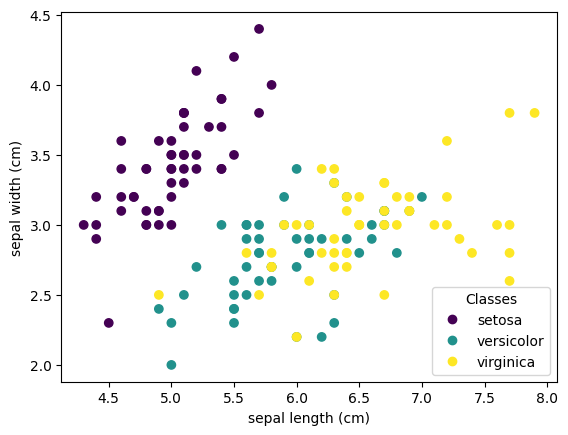

In [ ]:
# Crea un gráfico de dispersión para visualizar los datos de Iris
_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes")

In [ ]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [ ]:
v_medias=df.mean().values
m_cov=df.cov().values
m_corr=df.corr().values
print(v_medias)
print(m_cov)
print(m_corr)

[5.84333333 3.05733333 3.758      1.19933333]
[[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]


In [ ]:
df_copy=df.copy()
df_copy.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Introducción de Valores Faltantes y Preparación para la Imputación

Para simular la pérdida de datos, se crea una copia del DataFrame original (`df_copy`). Luego, se selecciona un 30% de las filas al azar y se les asigna `np.nan` (Not a Number) en la columna 'sepal width (cm)'.

Adicionalmente, se preparan los componentes necesarios para la imputación:

*   `mu_a`: Vector de medias de las variables observadas (las que no tendrán NaNs en este ejercicio: 'sepal length', 'petal length', 'petal width').
*   `mu_b`: Media de la variable con NaNs ('sepal width'), calculada solo con los valores presentes.
*   `S_aa`: Matriz de covarianza de las variables observadas.

In [ ]:
idx_b = df_copy.sample(frac=0.3, random_state=42).index
df_copy.loc[idx_b, 'sepal width (cm)'] = np.nan

mu_a=df_copy[['sepal length (cm)',
 'petal length (cm)',
 'petal width (cm)']].mean().values
mu_b=df_copy['sepal width (cm)'].mean()

S_aa= df_copy[['sepal length (cm)',
 'petal length (cm)',
 'petal width (cm)']].cov().values

print(v_medias)
print(m_cov)
print(m_corr)

[5.84333333 3.05733333 3.758      1.19933333]
[[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]


In [ ]:
idx_a_cols = [0, 2, 3]
idx_b_col = [1]

S_ba = m_cov[np.ix_(idx_b_col, idx_a_cols)]
S_bb = m_cov[np.ix_(idx_b_col, idx_b_col)]

In [ ]:
S_aa_inv = np.linalg.inv(S_aa)
print (S_aa_inv)

[[  6.23934975  -3.38033715   1.99378771]
 [ -3.38033715   6.23384436 -10.89740113]
 [  1.99378771 -10.89740113  24.25006752]]


### Proceso de Imputación de Valores Faltantes

En este paso, se itera sobre cada fila donde se introdujo un valor `NaN` en 'sepal width (cm)'. Para cada una de estas filas, se realiza la imputación utilizando la fórmula de la media condicional multivariante:

$$ E[X_b | X_a] = \mu_b + \Sigma_{ba} \Sigma_{aa}^{-1} (X_a - \mu_a) $$

Donde:
*   $E[X_b | X_a]$: Es el valor imputado para la variable $X_b$ (sepal width) dado el vector de variables observadas $X_a$.
*   $\mu_b$: Media de la variable $X_b$.
*   $\Sigma_{ba}$: Matriz de covarianza entre $X_b$ y $X_a$.
*   $\Sigma_{aa}^{-1}$: Inversa de la matriz de covarianza de $X_a$.
*   $X_a$: Vector de valores observados en la fila actual para las variables 'sepal length', 'petal length' y 'petal width'.
*   $\mu_a$: Vector de medias de las variables $X_a$.

El valor resultante `mu_b_given_a` se asigna a la columna 'sepal width (cm)' en el `df_imputed` para la fila correspondiente.

In [ ]:
df_imputed = df_copy.copy()

for i in idx_b:

    x_a = df_copy.loc[i, ['sepal length (cm)',
                          'petal length (cm)',
                          'petal width (cm)']].values
    #Fórmula MVN
    mu_b_given_a = mu_b + S_ba @ S_aa_inv @ (x_a - mu_a)

    df_imputed.loc[i, 'sepal width (cm)'] = mu_b_given_a[0]

### Evaluación de la Imputación

Para cuantificar qué tan bien se realizó la imputación, se calcula el Error Cuadrático Medio (MSE). Este métrica compara los valores originales de 'sepal width (cm)' (aquellos que fueron ocultados deliberadamente) con los valores que fueron imputados en sus lugares. Un MSE bajo indica que los valores imputados están cerca de los valores originales, sugiriendo una buena calidad de imputación.

In [ ]:
mask = df_copy['sepal width (cm)'].isna()

mse = np.mean(
    (df.loc[mask, 'sepal width (cm)'] -
     df_imputed.loc[mask, 'sepal width (cm)'])**2
)

print("MSE:", mse)

MSE: 0.0928024144187451


### Comparación Visual de las Distribuciones

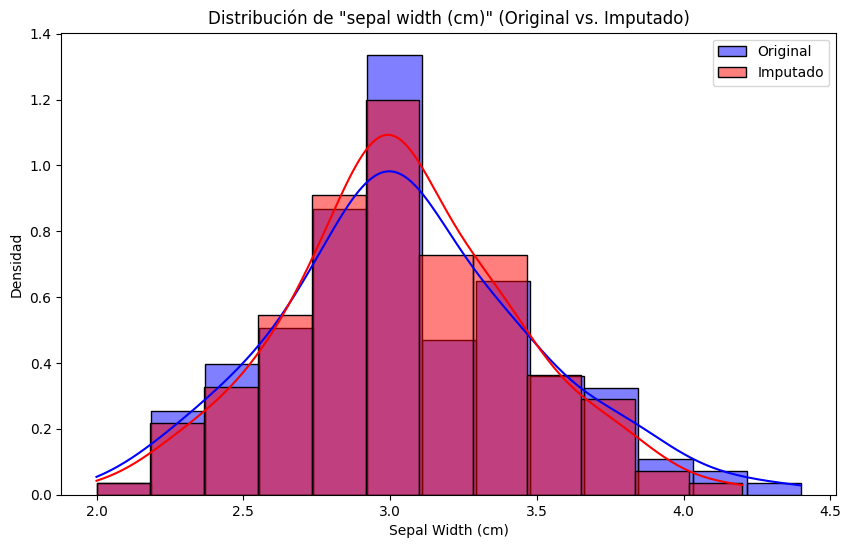

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sepal width (cm)'], color='blue', label='Original', kde=True, stat='density', alpha=0.5)
sns.histplot(df_imputed['sepal width (cm)'], color='red', label='Imputado', kde=True, stat='density', alpha=0.5)
plt.title('Distribución de "sepal width (cm)" (Original vs. Imputado)')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

### Gráfico de Dispersión de Valores Originales vs. Imputados

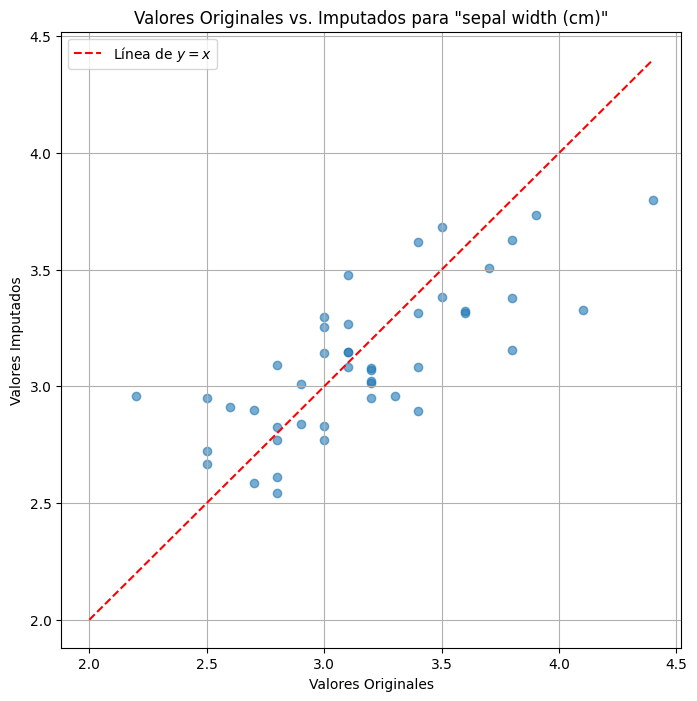

In [ ]:
# Solo para los valores que fueron imputados
plt.figure(figsize=(8, 8))
plt.scatter(df.loc[mask, 'sepal width (cm)'], df_imputed.loc[mask, 'sepal width (cm)'], alpha=0.6)
plt.plot([df['sepal width (cm)'].min(), df['sepal width (cm)'].max()],
         [df['sepal width (cm)'].min(), df['sepal width (cm)'].max()],
         '--r', label='Línea de $y=x$')
plt.title('Valores Originales vs. Imputados para "sepal width (cm)"')
plt.xlabel('Valores Originales')
plt.ylabel('Valores Imputados')
plt.grid(True)
plt.legend()
plt.show()

### Comparación de Estadísticas Descriptivas

In [ ]:
print('Estadísticas descriptivas para "sepal width (cm)" - Original:')
display(df['sepal width (cm)'].describe())

print('\nEstadísticas descriptivas para "sepal width (cm)" - Imputado:')
display(df_imputed['sepal width (cm)'].describe())

Estadísticas descriptivas para "sepal width (cm)" - Original:


,sepal width (cm)
count,150.000000
mean,3.057333
std,0.435866
min,2.000000
25%,2.800000
50%,3.000000
75%,3.300000
max,4.400000



Estadísticas descriptivas para "sepal width (cm)" - Imputado:


,sepal width (cm)
count,150.000000
mean,3.040353
std,0.392158
min,2.000000
25%,2.800000
50%,3.000000
75%,3.300000
max,4.200000
